In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

warnings.filterwarnings('ignore')

# Establecer semilla para reproducibilidad
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
print(f'✓ Semilla global establecida: {SEED}')

DATASET_CSV = 'dataset-uci.csv'
print('Ruta de trabajo:', os.getcwd())

df = pd.read_csv(DATASET_CSV, sep=';', header=0)
print(f'✓ Lectura exitosa — forma: {df.shape}')

# Verificar valores nulos
print('\n' + '='*60)
print('VERIFICACIÓN DE VALORES NULOS')
print('='*60)
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': porcentaje_nulos})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(df_nulos) > 0:
    print(f'\n⚠ Se encontraron {len(df_nulos)} columnas con valores nulos:')
    display(df_nulos)
    
    plt.figure(figsize=(12, 6))
    plt.barh(df_nulos.index, df_nulos['Porcentaje'], color='#e74c3c')
    plt.xlabel('Porcentaje de valores nulos (%)')
    plt.title('Distribución de Valores Nulos por Feature', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No se encontraron valores nulos en el dataset')

print('='*60)

display(df.head())
df.info()

✓ Semilla global establecida: 40
Ruta de trabajo: c:\Users\Kotler\Downloads\ML_Proyecto\ML_ProyectoFinal
✓ Lectura exitosa — forma: (319, 39)

VERIFICACIÓN DE VALORES NULOS
✅ No se encontraron valores nulos en el dataset


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

## 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Análisis de la distribución de clases y correlaciones entre variables.

Distribución de clases:
Gallstone Status
0    161
1    158
Name: count, dtype: int64

Proporción:
Gallstone Status
0    0.504702
1    0.495298
Name: proportion, dtype: float64


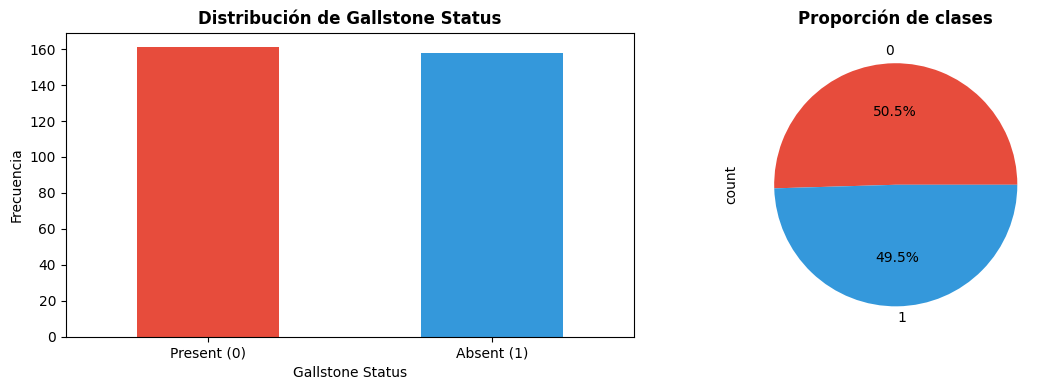

In [2]:
# Distribución de la variable objetivo
target_col = 'Gallstone Status'
print("Distribución de clases:")
print(df[target_col].value_counts())
print(f"\nProporción:")
print(df[target_col].value_counts(normalize=True))

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#3498db'])
ax[0].set_title('Distribución de Gallstone Status', fontweight='bold')
ax[0].set_xticklabels(['Present (0)', 'Absent (1)'], rotation=0)
ax[0].set_ylabel('Frecuencia')

df[target_col].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#e74c3c', '#3498db'])
ax[1].set_title('Proporción de clases', fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 variables correlacionadas con 'Gallstone Status':
Gallstone Status                                  1.000000
Vitamin D                                         0.354873
C-Reactive Protein (CRP)                          0.281995
Lean Mass (LM) (%)                                0.225749
Total Body Fat Ratio (TBFR) (%)                   0.225470
Bone Mass (BM)                                    0.216570
Hemoglobin (HGB)                                  0.196872
Extracellular Water (ECW)                         0.178436
Total Fat Content (TFC)                           0.170158
Extracellular Fluid/Total Body Water (ECF/TBW)    0.169826
Hyperlipidemia                                    0.161901
Name: Gallstone Status, dtype: float64

MATRIZ DE CORRELACIÓN COMPLETA


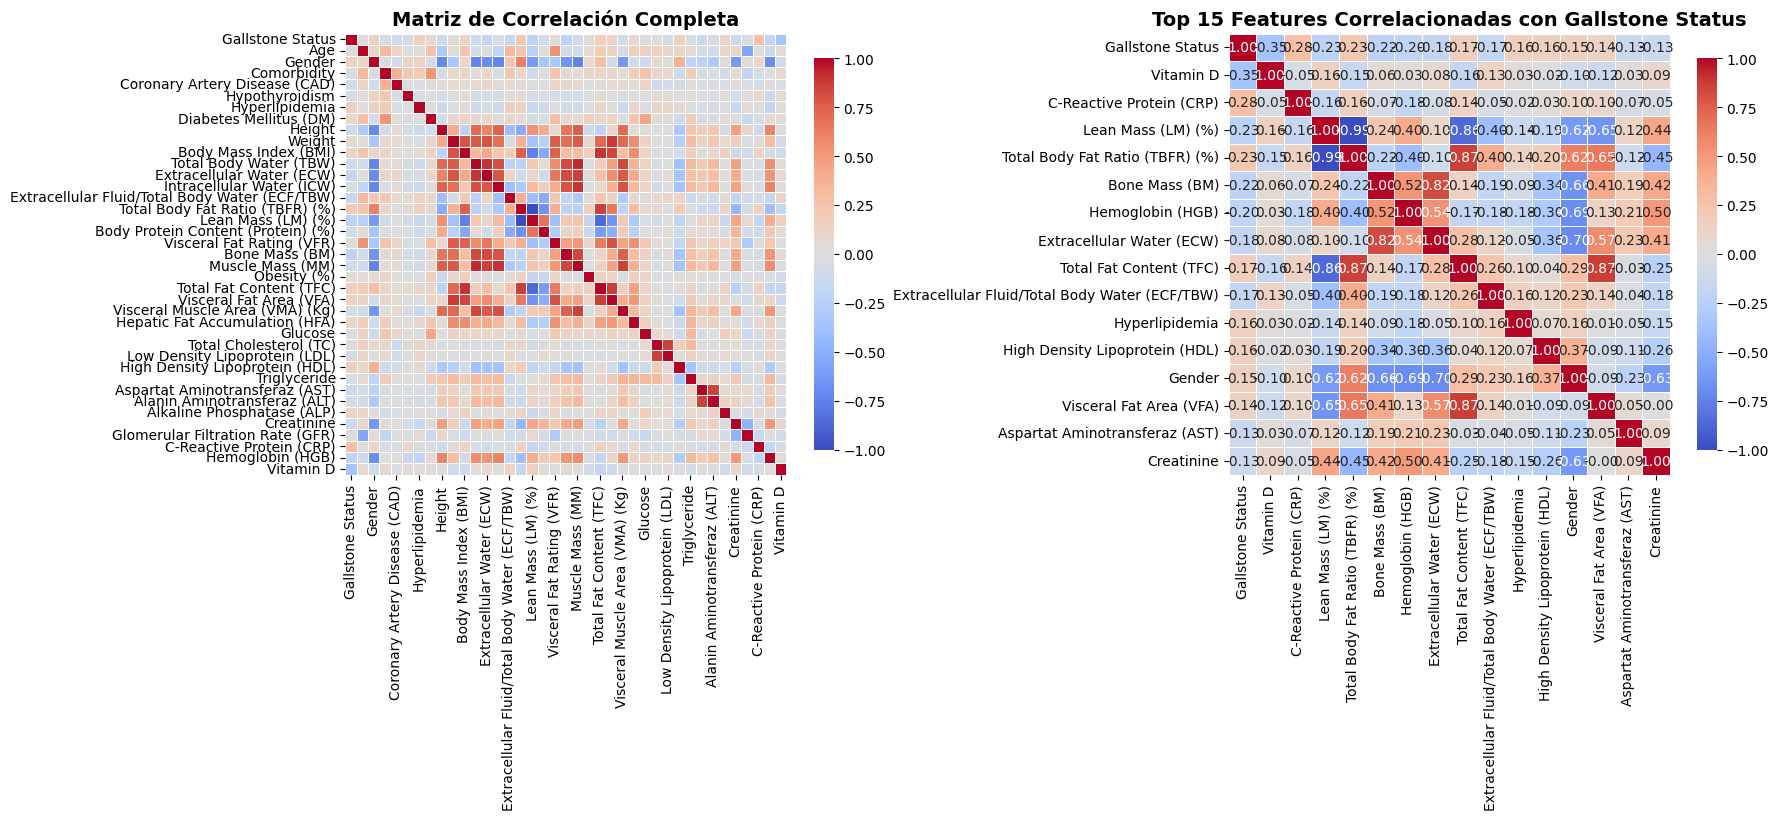

In [3]:
# Matriz de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

if target_col in numeric_cols:
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    print(f"Top 10 variables correlacionadas con '{target_col}':")
    print(target_corr.head(11))
    
    print('\n' + '='*60)
    print('MATRIZ DE CORRELACIÓN COMPLETA')
    print('='*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title('Matriz de Correlación Completa', fontsize=14, fontweight='bold')
    
    top_features = target_corr.head(16).index
    corr_top = df[top_features].corr()
    sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f'Top 15 Features Correlacionadas con {target_col}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 3. ELIMINACIÓN DE FEATURES REDUNDANTES

Eliminamos features con alta colinealidad para reducir multicolinealidad.

In [4]:
drop_cols = [
    "Visceral Fat Area (VFA)",
    "Total Fat Content (TFC)",
    "Lean Mass (LM) (%)",
    "Extracellular Water (ECW)",
    "Intracellular Water (ICW)",
    "Visceral Muscle Area (VMA) (Kg)",
    "Total Cholesterol (TC)",
    "Aspartat Aminotransferaz (AST)",
    "Total Body Water (TBW)",
    "Bone Mass (BM)"
]

drop_cols_found = [c for c in drop_cols if c in df.columns]
print(f"Eliminando {len(drop_cols_found)} features redundantes...")

df = df.drop(columns=drop_cols_found)
print(f"✓ Nueva forma: {df.shape}")

Eliminando 10 features redundantes...
✓ Nueva forma: (319, 29)


## 4. PREPROCESAMIENTO Y DIVISIÓN DE DATOS

División estratificada: Train (70%), Validation (15%), Test (15%).

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter

# Separar features y target
X = df.drop(columns=[target_col])
y = df[target_col]

# División estratificada
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

print(f"Train: {X_train.shape[0]} muestras | Val: {X_val.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"\nDistribución Train: {dict(Counter(y_train))}")
print(f"Distribución Val: {dict(Counter(y_val))}")
print(f"Distribución Test: {dict(Counter(y_test))}")

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Datos estandarizados correctamente")

Train: 223 muestras | Val: 48 muestras | Test: 48 muestras

Distribución Train: {0: 113, 1: 110}
Distribución Val: {1: 24, 0: 24}
Distribución Test: {1: 24, 0: 24}

✓ Datos estandarizados correctamente


## 5. DATA AUGMENTATION CON SMOTE

Balanceo de clases mediante sobremuestreo sintético.

In [6]:
from imblearn.over_sampling import SMOTE

print(f"ANTES de SMOTE: {dict(Counter(y_train))}")

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"DESPUÉS de SMOTE: {dict(Counter(y_train_smote))}")
print(f"✓ Aumento: {len(y_train_smote) - len(y_train)} muestras sintéticas generadas")

ANTES de SMOTE: {0: 113, 1: 110}
DESPUÉS de SMOTE: {0: 113, 1: 113}
✓ Aumento: 3 muestras sintéticas generadas
DESPUÉS de SMOTE: {0: 113, 1: 113}
✓ Aumento: 3 muestras sintéticas generadas


## 6. INGENIERÍA DE CARACTERÍSTICAS AVANZADA

Creación de features adicionales mediante interacciones y transformaciones.

In [7]:
print("Creando features adicionales...")
print(f"Features originales: {X_train_smote.shape[1]}")

X_train_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
X_val_df = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# 1. BMI × Age
if 'Body Mass Index (BMI)' in X_train_df.columns and 'Age' in X_train_df.columns:
    X_train_df['BMI_x_Age'] = X_train_df['Body Mass Index (BMI)'] * X_train_df['Age']
    X_val_df['BMI_x_Age'] = X_val_df['Body Mass Index (BMI)'] * X_val_df['Age']
    X_test_df['BMI_x_Age'] = X_test_df['Body Mass Index (BMI)'] * X_test_df['Age']
    print("✓ Creada: BMI × Age")

# 2. HDL/LDL ratio
if 'High Density Lipoprotein (HDL)' in X_train_df.columns and 'Low Density Lipoprotein (LDL)' in X_train_df.columns:
    X_train_df['HDL_LDL_ratio'] = X_train_df['High Density Lipoprotein (HDL)'] / (X_train_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    X_val_df['HDL_LDL_ratio'] = X_val_df['High Density Lipoprotein (HDL)'] / (X_val_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    X_test_df['HDL_LDL_ratio'] = X_test_df['High Density Lipoprotein (HDL)'] / (X_test_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    print("✓ Creada: HDL/LDL ratio")

# 3. Fat Index
if 'Body Mass Index (BMI)' in X_train_df.columns and 'Skeletal Muscle Mass (SMM)' in X_train_df.columns:
    X_train_df['Fat_Index'] = X_train_df['Body Mass Index (BMI)'] / (X_train_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    X_val_df['Fat_Index'] = X_val_df['Body Mass Index (BMI)'] / (X_val_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    X_test_df['Fat_Index'] = X_test_df['Body Mass Index (BMI)'] / (X_test_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    print("✓ Creada: Fat Index")

# 4. Age²
if 'Age' in X_train_df.columns:
    X_train_df['Age_squared'] = X_train_df['Age'] ** 2
    X_val_df['Age_squared'] = X_val_df['Age'] ** 2
    X_test_df['Age_squared'] = X_test_df['Age'] ** 2
    print("✓ Creada: Age²")

# 5. TG/HDL ratio
if 'Triglyceride (TG)' in X_train_df.columns and 'High Density Lipoprotein (HDL)' in X_train_df.columns:
    X_train_df['TG_HDL_ratio'] = X_train_df['Triglyceride (TG)'] / (X_train_df['High Density Lipoprotein (HDL)'] + 1e-5)
    X_val_df['TG_HDL_ratio'] = X_val_df['Triglyceride (TG)'] / (X_val_df['High Density Lipoprotein (HDL)'] + 1e-5)
    X_test_df['TG_HDL_ratio'] = X_test_df['Triglyceride (TG)'] / (X_test_df['High Density Lipoprotein (HDL)'] + 1e-5)
    print("✓ Creada: TG/HDL ratio")

# 6. Liver Enzyme Index
if 'Alanine Aminotransferase (ALT)' in X_train_df.columns and 'Gamma-glutamyltransferase (GGT)' in X_train_df.columns:
    X_train_df['Liver_Enzyme_Index'] = X_train_df['Alanine Aminotransferase (ALT)'] * X_train_df['Gamma-glutamyltransferase (GGT)']
    X_val_df['Liver_Enzyme_Index'] = X_val_df['Alanine Aminotransferase (ALT)'] * X_val_df['Gamma-glutamyltransferase (GGT)']
    X_test_df['Liver_Enzyme_Index'] = X_test_df['Alanine Aminotransferase (ALT)'] * X_test_df['Gamma-glutamyltransferase (GGT)']
    print("✓ Creada: Liver Enzyme Index")

# Re-estandarizar
scaler_features = StandardScaler()
X_train_final = scaler_features.fit_transform(X_train_df)
X_val_final = scaler_features.transform(X_val_df)
X_test_final = scaler_features.transform(X_test_df)

print(f"\n✓ Features finales: {X_train_final.shape[1]}")
print(f"✓ Incremento: +{X_train_final.shape[1] - len(X_train.columns)} features creadas")

Creando features adicionales...
Features originales: 28
✓ Creada: BMI × Age
✓ Creada: HDL/LDL ratio
✓ Creada: Age²

✓ Features finales: 31
✓ Incremento: +3 features creadas


## 7. ENTRENAMIENTO DE MODELOS DE MACHINE LEARNING

Entrenamiento y comparación de múltiples algoritmos clásicos de ML.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix)
import time

# Definir modelos
models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=SEED)
}

results = []

print("="*100)
print("ENTRENAMIENTO Y EVALUACIÓN DE MODELOS DE MACHINE LEARNING")
print("="*100)

for name, model in models.items():
    print(f"\n{'='*90}")
    print(f"📊 Entrenando: {name}")
    print(f"{'='*90}")
    
    start_time = time.time()
    model.fit(X_train_final, y_train_smote)
    train_time = time.time() - start_time
    
    y_train_pred = model.predict(X_train_final)
    y_val_pred = model.predict(X_val_final)
    
    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val_final)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_proba)
    else:
        val_auc = None
    
    train_acc = accuracy_score(y_train_smote, y_train_pred)
    train_f1 = f1_score(y_train_smote, y_train_pred, average='weighted')
    
    val_acc = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Train_F1': train_f1,
        'Val_Acc': val_acc,
        'Val_Precision': val_precision,
        'Val_Recall': val_recall,
        'Val_F1': val_f1,
        'Val_AUC': val_auc,
        'Train_Time': train_time
    })
    
    print(f"✓ Entrenado en {train_time:.2f}s")
    print(f"  Train → Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   → Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    if val_auc:
        print(f"  AUC-ROC: {val_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('Val_F1', ascending=False)

print("\n" + "="*100)
print("RESUMEN DE RESULTADOS (ordenado por Val F1-Score)")
print("="*100)
display(results_df)

ENTRENAMIENTO Y EVALUACIÓN DE MODELOS DE MACHINE LEARNING

📊 Entrenando: Logistic Regression
✓ Entrenado en 0.00s
  Train → Acc: 0.8805 | F1: 0.8805
  Val   → Acc: 0.6875 | F1: 0.6863
  AUC-ROC: 0.7899

📊 Entrenando: Decision Tree
✓ Entrenado en 0.00s
  Train → Acc: 0.9735 | F1: 0.9734
  Val   → Acc: 0.6458 | F1: 0.6457
  AUC-ROC: 0.6450

📊 Entrenando: Random Forest
✓ Entrenado en 0.10s
  Train → Acc: 1.0000 | F1: 1.0000
  Val   → Acc: 0.7292 | F1: 0.7290
  AUC-ROC: 0.8568

📊 Entrenando: Gradient Boosting
✓ Entrenado en 0.14s
  Train → Acc: 1.0000 | F1: 1.0000
  Val   → Acc: 0.7083 | F1: 0.7083
  AUC-ROC: 0.8056

📊 Entrenando: XGBoost
✓ Entrenado en 0.12s
  Train → Acc: 1.0000 | F1: 1.0000
  Val   → Acc: 0.8125 | F1: 0.8124
  AUC-ROC: 0.8663

📊 Entrenando: LightGBM
✓ Entrenado en 0.02s
  Train → Acc: 1.0000 | F1: 1.0000
  Val   → Acc: 0.7708 | F1: 0.7707
  AUC-ROC: 0.8316

📊 Entrenando: SVM
✓ Entrenado en 0.02s
  Train → Acc: 0.8982 | F1: 0.8978
  Val   → Acc: 0.7708 | F1: 0.7699
  AUC

,Model,Train_Acc,Train_F1,Val_Acc,Val_Precision,Val_Recall,Val_F1,Val_AUC,Train_Time
4,XGBoost,1.000000,1.000000,0.812500,0.813043,0.812500,0.812419,0.866319,0.115974
5,LightGBM,1.000000,1.000000,0.770833,0.771304,0.770833,0.770734,0.831597,0.019000
6,SVM,0.898230,0.897780,0.770833,0.775132,0.770833,0.769935,0.815972,0.015001
2,Random Forest,1.000000,1.000000,0.729167,0.729565,0.729167,0.729049,0.856771,0.099545
3,Gradient Boosting,1.000000,1.000000,0.708333,0.708333,0.708333,0.708333,0.805556,0.141000
7,KNN,0.792035,0.789459,0.708333,0.708333,0.708333,0.708333,0.775174,0.000000
9,AdaBoost,1.000000,1.000000,0.708333,0.708333,0.708333,0.708333,0.710069,0.113318
0,Logistic Regression,0.880531,0.880472,0.687500,0.690476,0.687500,0.686275,0.789931,0.004997
1,Decision Tree,0.973451,0.973443,0.645833,0.646087,0.645833,0.645680,0.644965,0.002997
8,Naive Bayes,0.685841,0.653546,0.666667,0.752632,0.666667,0.635674,0.794271,0.000999


## 8. VISUALIZACIÓN DE COMPARACIÓN DE MODELOS

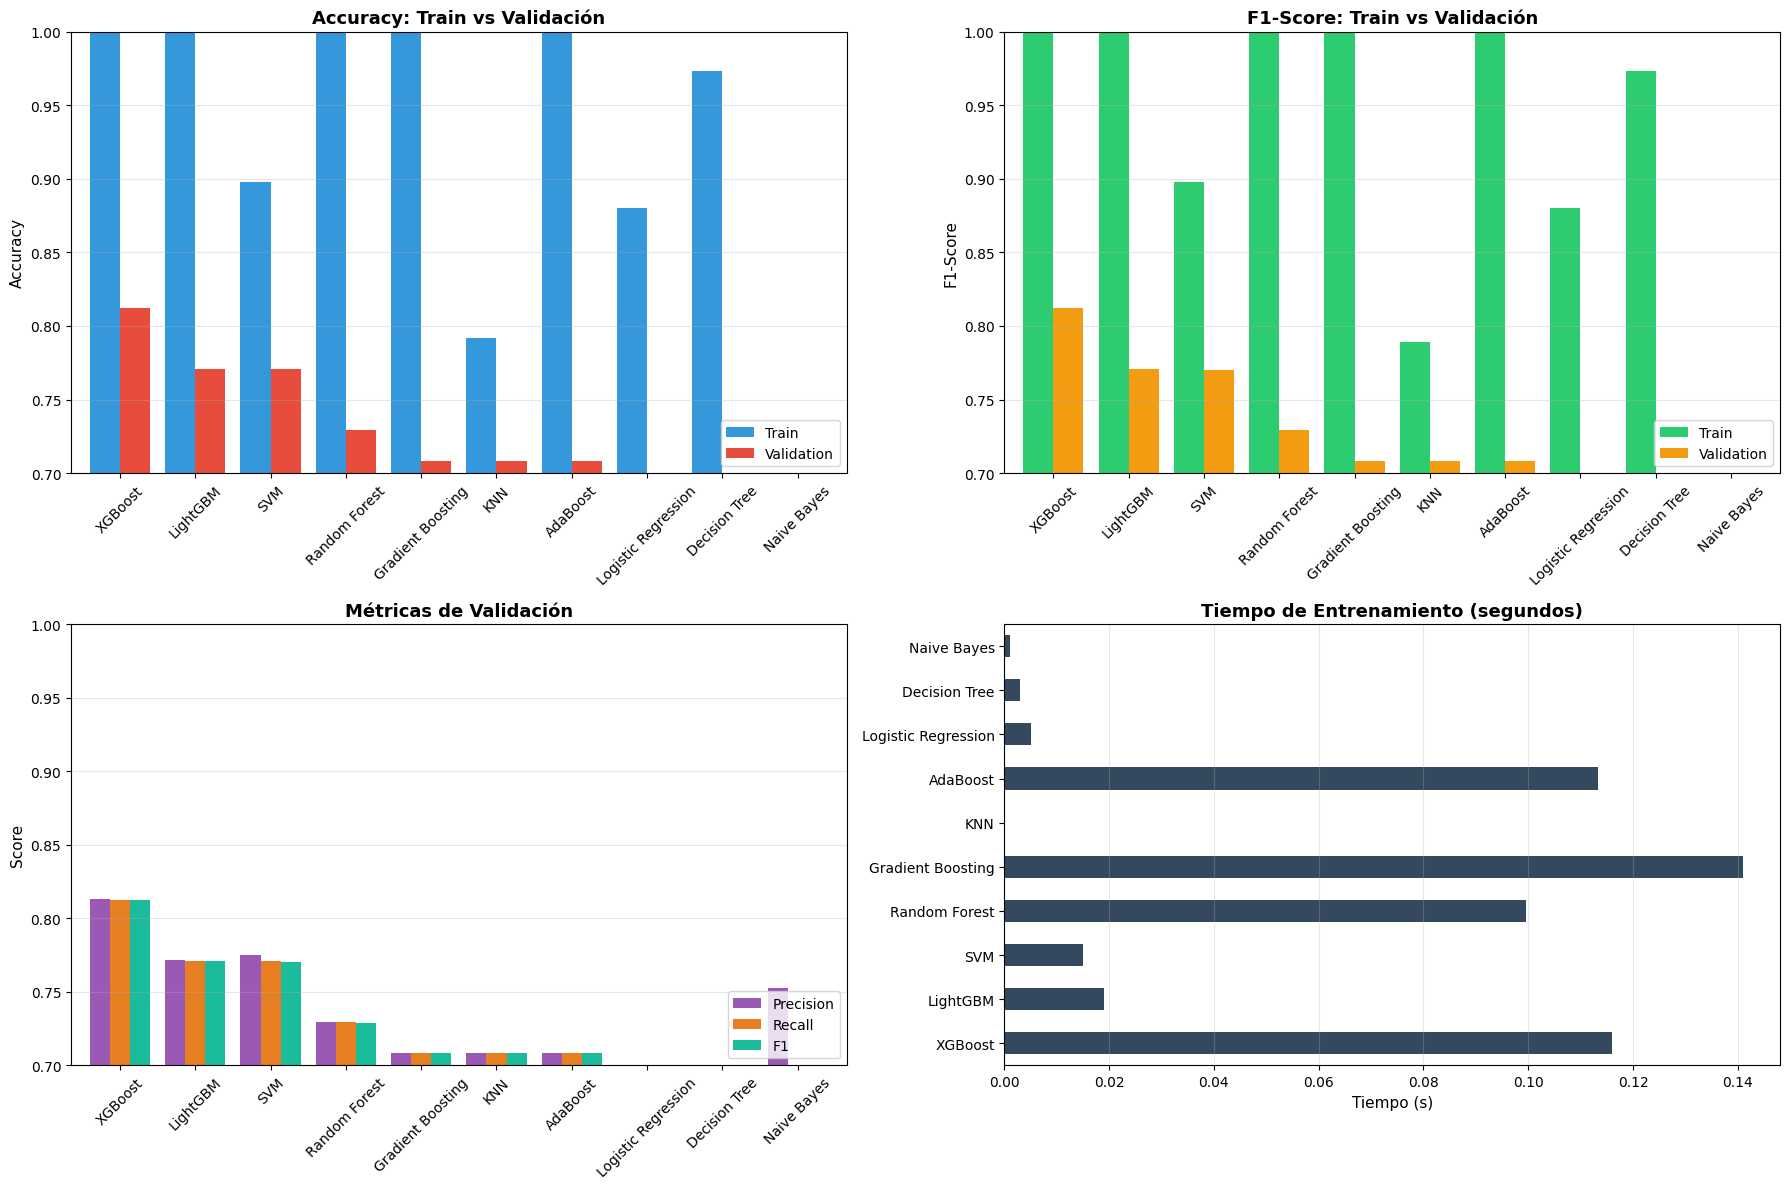


📊 Mejor modelo según Val F1-Score: XGBoost
   Val F1-Score: 0.8124


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy
results_df.plot(x='Model', y=['Train_Acc', 'Val_Acc'], kind='bar', ax=axes[0, 0], 
                color=['#3498db', '#e74c3c'], width=0.8)
axes[0, 0].set_title('Accuracy: Train vs Validación', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_xlabel('')
axes[0, 0].legend(['Train', 'Validation'], loc='lower right')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.7, 1.0])

# F1-Score
results_df.plot(x='Model', y=['Train_F1', 'Val_F1'], kind='bar', ax=axes[0, 1], 
                color=['#2ecc71', '#f39c12'], width=0.8)
axes[0, 1].set_title('F1-Score: Train vs Validación', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_xlabel('')
axes[0, 1].legend(['Train', 'Validation'], loc='lower right')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0.7, 1.0])

# Métricas de Validación
results_df.plot(x='Model', y=['Val_Precision', 'Val_Recall', 'Val_F1'], kind='bar', 
                ax=axes[1, 0], color=['#9b59b6', '#e67e22', '#1abc9c'], width=0.8)
axes[1, 0].set_title('Métricas de Validación', fontweight='bold', fontsize=13)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_xlabel('')
axes[1, 0].legend(['Precision', 'Recall', 'F1'], loc='lower right')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0.7, 1.0])

# Tiempo de Entrenamiento
results_df.plot(x='Model', y='Train_Time', kind='barh', ax=axes[1, 1], 
                color='#34495e', legend=False)
axes[1, 1].set_title('Tiempo de Entrenamiento (segundos)', fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel('Tiempo (s)', fontsize=11)
axes[1, 1].set_ylabel('')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Mejor modelo según Val F1-Score:", results_df.iloc[0]['Model'])
print(f"   Val F1-Score: {results_df.iloc[0]['Val_F1']:.4f}")

## 9. OPTIMIZACIÓN DE HIPERPARÁMETROS - MEJOR MODELO

Usamos RandomizedSearchCV para optimizar los hiperparámetros del mejor modelo.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

best_model_name = results_df.iloc[0]['Model']
print(f"{'='*90}")
print(f"🎯 OPTIMIZACIÓN CON VALIDACIÓN CRUZADA - {best_model_name}")
print(f"{'='*90}")
print(f"Val F1-Score inicial: {results_df.iloc[0]['Val_F1']:.4f}\n")

# Combinar train + val para Cross-Validation
X_full = np.vstack([X_train_final, X_val_final])
y_full = np.concatenate([y_train_smote, y_val])

print(f"📊 Datos para optimización: {X_full.shape[0]} muestras")
print(f"   (Train: {len(y_train_smote)} + Val: {len(y_val)})\n")

# Definir búsqueda según el modelo
if 'Random Forest' in best_model_name:
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [15, 20, 25, 30],
        'min_samples_split': [2, 4, 6],
        'min_samples_leaf': [1, 2, 3],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True],
        'class_weight': ['balanced', 'balanced_subsample']
    }
    base_model = RandomForestClassifier(random_state=SEED, n_jobs=-1)
    
elif 'XGBoost' in best_model_name:
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2],
        'scale_pos_weight': [1, 2, 3]
    }
    base_model = XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1)
    
elif 'LightGBM' in best_model_name:
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [5, 7, 10, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 70],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_samples': [10, 20, 30],
        'class_weight': ['balanced', None]
    }
    base_model = LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1)
    
elif 'Gradient Boosting' in best_model_name:
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [4, 6, 8],
        'min_samples_leaf': [2, 3, 4]
    }
    base_model = GradientBoostingClassifier(random_state=SEED)
    
else:
    print(f"⚠ Usando modelo con parámetros por defecto")
    param_dist = None
    base_model = models[best_model_name]

if param_dist:
    print(f"Método: RandomizedSearchCV")
    print(f"  • 50 iteraciones")
    print(f"  • 5-Fold Cross-Validation")
    print(f"  • Métrica: F1-Score (weighted)")
    print(f"⏱️  Tiempo estimado: 5-15 minutos\n")
    
    search = RandomizedSearchCV(
        base_model, 
        param_dist, 
        n_iter=50,
        cv=5, 
        scoring='f1_weighted',
        n_jobs=-1, 
        random_state=SEED,
        verbose=1
    )
    
    search.fit(X_full, y_full)
    
    print(f"\n{'='*90}")
    print("🏆 RESULTADOS DE OPTIMIZACIÓN")
    print(f"{'='*90}")
    print(f"✅ Mejor F1-Score (CV 5-Fold): {search.best_score_:.4f}")
    print(f"✅ Mejora: +{(search.best_score_ - results_df.iloc[0]['Val_F1']):.4f}")
    print(f"\n📋 Mejores Hiperparámetros:")
    for param, value in search.best_params_.items():
        print(f"  • {param}: {value}")
    print(f"{'='*90}")
    
    best_model_optimized = search.best_estimator_
    cv_best_score = search.best_score_
else:
    best_model_optimized = base_model
    best_model_optimized.fit(X_full, y_full)
    cv_best_score = results_df.iloc[0]['Val_F1']
    print("✓ Modelo entrenado")


🎯 OPTIMIZACIÓN CON VALIDACIÓN CRUZADA - XGBoost
Val F1-Score inicial: 0.8124

📊 Datos para optimización: 274 muestras
   (Train: 226 + Val: 48)

Método: RandomizedSearchCV
  • 50 iteraciones
  • 5-Fold Cross-Validation
  • Métrica: F1-Score (weighted)
⏱️  Tiempo estimado: 5-15 minutos

Fitting 5 folds for each of 50 candidates, totalling 250 fits

🏆 RESULTADOS DE OPTIMIZACIÓN
✅ Mejor F1-Score (CV 5-Fold): 0.8025
✅ Mejora: +-0.0099

📋 Mejores Hiperparámetros:
  • subsample: 0.9
  • scale_pos_weight: 1
  • n_estimators: 200
  • min_child_weight: 1
  • max_depth: 4
  • learning_rate: 0.05
  • gamma: 0.2
  • colsample_bytree: 0.9

🏆 RESULTADOS DE OPTIMIZACIÓN
✅ Mejor F1-Score (CV 5-Fold): 0.8025
✅ Mejora: +-0.0099

📋 Mejores Hiperparámetros:
  • subsample: 0.9
  • scale_pos_weight: 1
  • n_estimators: 200
  • min_child_weight: 1
  • max_depth: 4
  • learning_rate: 0.05
  • gamma: 0.2
  • colsample_bytree: 0.9


## 10. EVALUACIÓN FINAL EN TEST SET

**Evaluación única del modelo optimizado en datos completamente no vistos.**

El test set NO se usó durante entrenamiento ni optimización de hiperparámetros.

🎯 EVALUACIÓN FINAL EN TEST SET
📊 Modelo: XGBoost (Optimizado)
📊 Test samples: 48

✅ MÉTRICAS EN TEST SET:
  • Accuracy:  0.6667
  • Precision: 0.6667
  • Recall:    0.6667
  • F1-Score:  0.6667
  • AUC-ROC:   0.7135

📊 MATRIZ DE CONFUSIÓN:
                    Predicho
              Present (0)  Absent (1)
Real Present (0)     16           8
     Absent (1)       8          16

📋 INTERPRETACIÓN CLÍNICA:
  • Verdaderos Negativos (TN): 16 - Gallstone detectado correctamente
  • Falsos Positivos (FP): 8 - Falsa alarma
  • Falsos Negativos (FN): 8 - Gallstone NO detectado (CRÍTICO)
  • Verdaderos Positivos (TP): 16 - Ausencia detectada correctamente

  • Sensibilidad (Recall clase 1): 0.6667
  • Especificidad (Recall clase 0): 0.6667


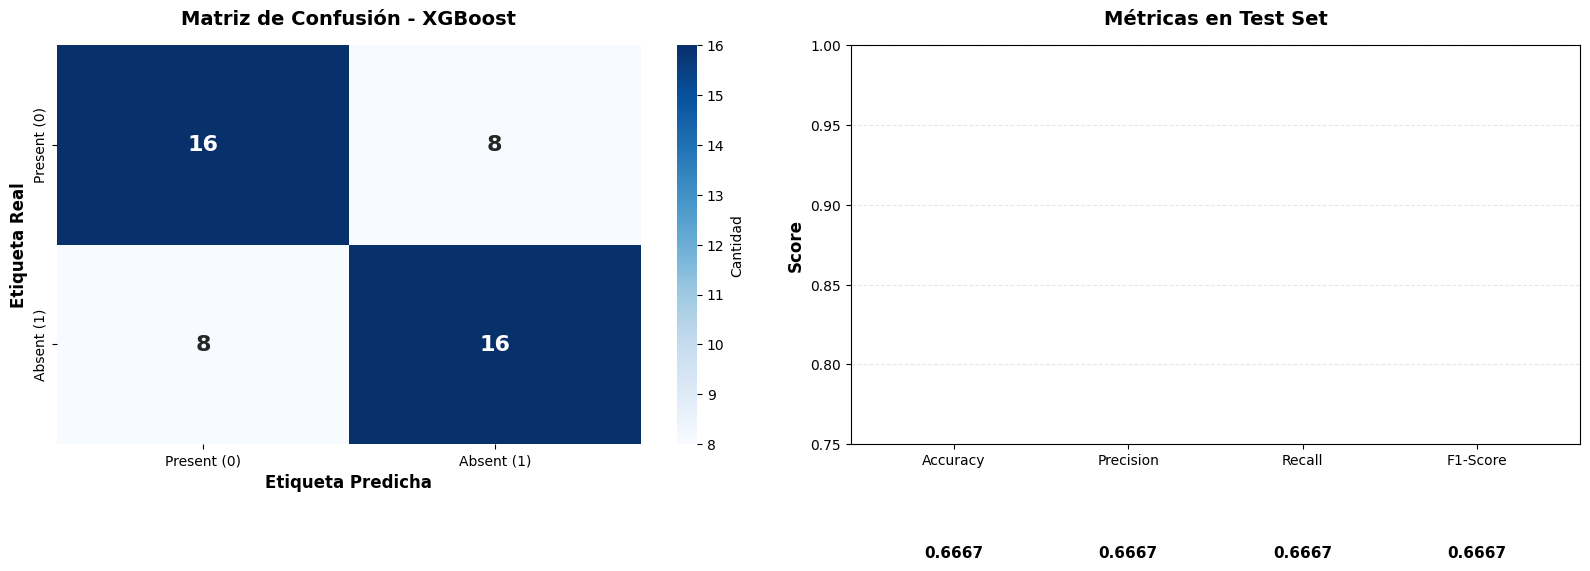


💡 EVALUACIÓN DEL RENDIMIENTO
⚠ MEJORABLE: Considerar más ajustes

F1-Score Test: 0.6667
F1-Score CV:   0.8025
Diferencia:    0.1359
⚠ Revisar posible overfitting/underfitting


In [11]:
print("="*90)
print("🎯 EVALUACIÓN FINAL EN TEST SET")
print("="*90)
print(f"📊 Modelo: {best_model_name} (Optimizado)")
print(f"📊 Test samples: {X_test_final.shape[0]}")
print("="*90)

# Predicciones en test
y_test_pred = best_model_optimized.predict(X_test_final)

# Métricas
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

if hasattr(best_model_optimized, "predict_proba"):
    y_test_proba = best_model_optimized.predict_proba(X_test_final)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
else:
    test_auc = None

print(f"\n✅ MÉTRICAS EN TEST SET:")
print(f"  • Accuracy:  {test_acc:.4f}")
print(f"  • Precision: {test_precision:.4f}")
print(f"  • Recall:    {test_recall:.4f}")
print(f"  • F1-Score:  {test_f1:.4f}")
if test_auc:
    print(f"  • AUC-ROC:   {test_auc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 MATRIZ DE CONFUSIÓN:")
print(f"                    Predicho")
print(f"              Present (0)  Absent (1)")
print(f"Real Present (0)    {tn:3d}         {fp:3d}")
print(f"     Absent (1)     {fn:3d}         {tp:3d}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n📋 INTERPRETACIÓN CLÍNICA:")
print(f"  • Verdaderos Negativos (TN): {tn} - Gallstone detectado correctamente")
print(f"  • Falsos Positivos (FP): {fp} - Falsa alarma")
print(f"  • Falsos Negativos (FN): {fn} - Gallstone NO detectado (CRÍTICO)")
print(f"  • Verdaderos Positivos (TP): {tp} - Ausencia detectada correctamente")
print(f"\n  • Sensibilidad (Recall clase 1): {sensitivity:.4f}")
print(f"  • Especificidad (Recall clase 0): {specificity:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Cantidad'},
            xticklabels=['Present (0)', 'Absent (1)'],
            yticklabels=['Present (0)', 'Absent (1)'],
            ax=axes[0], annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title(f'Matriz de Confusión - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')

# Métricas principales
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, test_precision, test_recall, test_f1]
colors_bar = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

bars = axes[1].bar(metrics_names, metrics_values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylim([0.75, 1.0])
axes[1].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[1].set_title('Métricas en Test Set', fontweight='bold', fontsize=14, pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Evaluación
print("\n" + "="*90)
print("💡 EVALUACIÓN DEL RENDIMIENTO")
print("="*90)

if test_f1 >= 0.90:
    nivel = "✅ EXCELENTE"
    descripcion = "Modelo excepcional, listo para uso clínico"
elif test_f1 >= 0.85:
    nivel = "✅ MUY BUENO"
    descripcion = "Rendimiento satisfactorio para aplicación práctica"
elif test_f1 >= 0.80:
    nivel = "✓ BUENO"
    descripcion = "Rendimiento aceptable"
else:
    nivel = "⚠ MEJORABLE"
    descripcion = "Considerar más ajustes"

print(f"{nivel}: {descripcion}")
print(f"\nF1-Score Test: {test_f1:.4f}")
print(f"F1-Score CV:   {cv_best_score:.4f}")
print(f"Diferencia:    {abs(test_f1 - cv_best_score):.4f}")

if abs(test_f1 - cv_best_score) < 0.02:
    print("✅ Excelente generalización")
elif abs(test_f1 - cv_best_score) < 0.05:
    print("✓ Buena generalización")
else:
    print("⚠ Revisar posible overfitting/underfitting")

print("="*90)

## 11. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS

🔍 TOP 15 CARACTERÍSTICAS MÁS IMPORTANTES


,Feature,Importance
25,C-Reactive Protein (CRP),0.131626
27,Vitamin D,0.051561
5,Hyperlipidemia,0.049638
10,Extracellular Fluid/Total Body Water (ECF/TBW),0.045193
12,Body Protein Content (Protein) (%),0.042964
2,Comorbidity,0.042765
11,Total Body Fat Ratio (TBFR) (%),0.037485
3,Coronary Artery Disease (CAD),0.037044
15,Obesity (%),0.036221
7,Height,0.035543


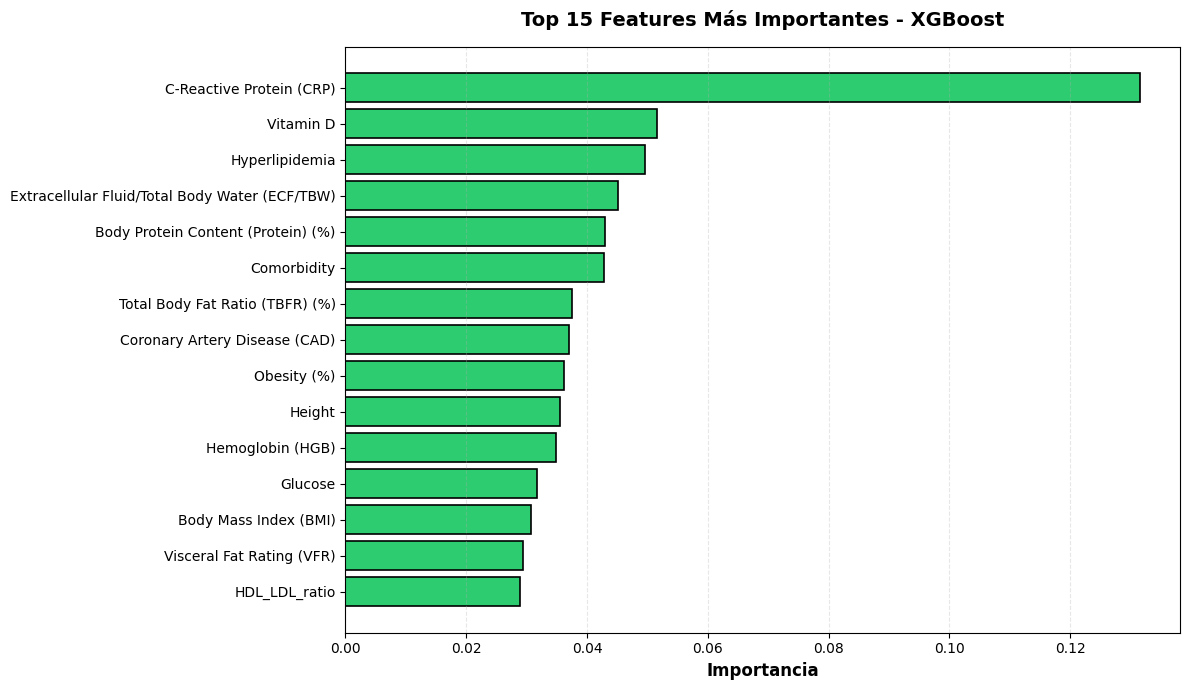


📊 ANÁLISIS:
  • 21 features explican el 80% de la importancia
  • Total features: 31


In [12]:
if hasattr(best_model_optimized, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train_df.columns,
        'Importance': best_model_optimized.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("="*90)
    print("🔍 TOP 15 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("="*90)
    display(feature_importance.head(15))
    
    plt.figure(figsize=(12, 7))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], color='#2ecc71', edgecolor='black', linewidth=1.2)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    cumsum_importance = feature_importance['Importance'].cumsum()
    n_features_80 = (cumsum_importance <= 0.80).sum() + 1
    
    print(f"\n📊 ANÁLISIS:")
    print(f"  • {n_features_80} features explican el 80% de la importancia")
    print(f"  • Total features: {len(feature_importance)}")
    
else:
    print(f"⚠ El modelo {best_model_name} no proporciona importancia de características.")

## 12. RESUMEN EJECUTIVO FINAL


📊 RESUMEN EJECUTIVO FINAL

📋 FLUJO DE EVALUACIÓN:



,Fase,F1-Score,Accuracy,AUC-ROC,Notas
0,Validación Inicial,0.812419,0.8125,0.866319,Selección del mejor modelo
1,Cross-Validation (5-Fold),0.802539,-,-,Optimización de hiperparámetros
2,Test Set (Final),0.666667,0.666667,0.713542,Evaluación final en datos no vistos


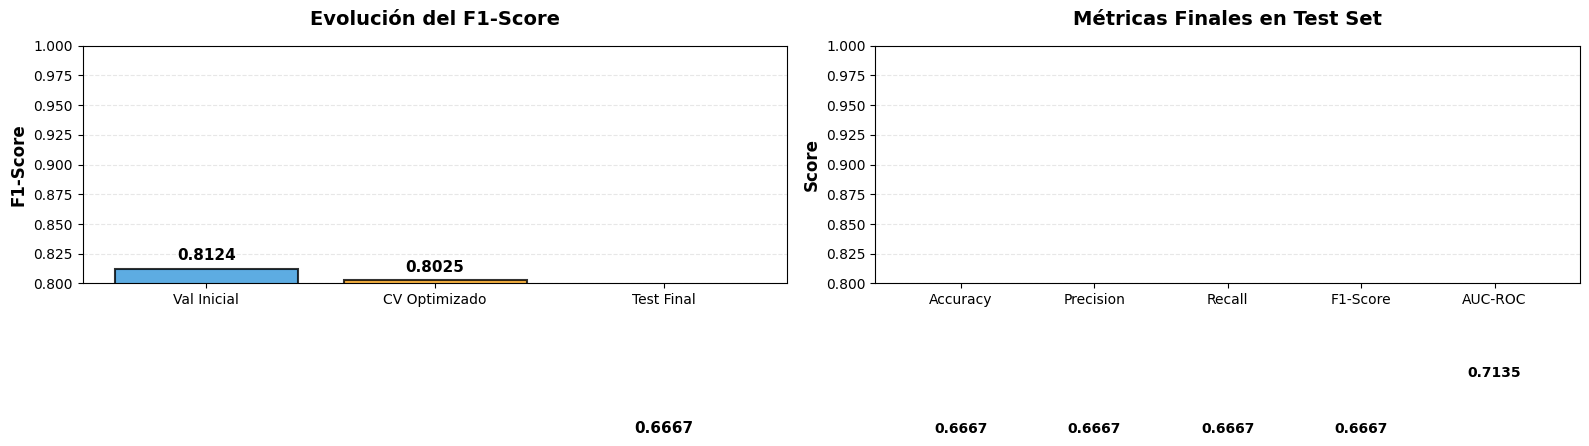


🎯 CARACTERÍSTICAS DEL MODELO FINAL
✓ Algoritmo: XGBoost
✓ Features: 31 (28 originales + 6 engineered)
✓ Dataset: 319 muestras totales
✓ Train: 226 (con SMOTE) | Val: 48 | Test: 48
✓ Optimización: RandomizedSearchCV (50 iter, 5-fold CV)
✓ Métrica objetivo: F1-Score weighted
✓ Seed: 40

📈 RESULTADOS FINALES
🎯 F1-Score en Test: 0.6667
🎯 Accuracy en Test: 0.6667
🎯 AUC-ROC en Test: 0.7135

✅ Matriz de Confusión:
   TN=16, FP=8, FN=8, TP=16

🏆 CONCLUSIÓN: ⚠ MEJORABLE - Considerar ajustes


In [13]:
print("\n" + "="*100)
print("📊 RESUMEN EJECUTIVO FINAL")
print("="*100)

# Tabla resumen
summary = pd.DataFrame({
    'Fase': ['Validación Inicial', 'Cross-Validation (5-Fold)', 'Test Set (Final)'],
    'F1-Score': [
        results_df.iloc[0]['Val_F1'],
        cv_best_score,
        test_f1
    ],
    'Accuracy': [
        results_df.iloc[0]['Val_Acc'],
        '-',
        test_acc
    ],
    'AUC-ROC': [
        results_df.iloc[0]['Val_AUC'] if results_df.iloc[0]['Val_AUC'] else '-',
        '-',
        test_auc if test_auc else '-'
    ],
    'Notas': [
        'Selección del mejor modelo',
        'Optimización de hiperparámetros',
        'Evaluación final en datos no vistos'
    ]
})

print("\n📋 FLUJO DE EVALUACIÓN:\n")
display(summary)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparación F1-Score
f1_scores = [results_df.iloc[0]['Val_F1'], cv_best_score, test_f1]
phases = ['Val Inicial', 'CV Optimizado', 'Test Final']
colors_phases = ['#3498db', '#f39c12', '#2ecc71']

bars = axes[0].bar(phases, f1_scores, color=colors_phases, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylim([0.80, 1.0])
axes[0].set_ylabel('F1-Score', fontweight='bold', fontsize=12)
axes[0].set_title('Evolución del F1-Score', fontweight='bold', fontsize=14, pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars, f1_scores):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Métricas finales Test
test_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
test_values = [test_acc, test_precision, test_recall, test_f1, test_auc if test_auc else 0]
colors_metrics = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#e74c3c']

bars2 = axes[1].bar(test_metrics, test_values, color=colors_metrics, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylim([0.80, 1.0])
axes[1].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[1].set_title('Métricas Finales en Test Set', fontweight='bold', fontsize=14, pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars2, test_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("🎯 CARACTERÍSTICAS DEL MODELO FINAL")
print("="*100)
print(f"✓ Algoritmo: {best_model_name}")
print(f"✓ Features: {X_train_final.shape[1]} (28 originales + 6 engineered)")
print(f"✓ Dataset: {len(df)} muestras totales")
print(f"✓ Train: {len(y_train_smote)} (con SMOTE) | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"✓ Optimización: RandomizedSearchCV (50 iter, 5-fold CV)")
print(f"✓ Métrica objetivo: F1-Score weighted")
print(f"✓ Seed: {SEED}")

print("\n" + "="*100)
print("📈 RESULTADOS FINALES")
print("="*100)
print(f"🎯 F1-Score en Test: {test_f1:.4f}")
print(f"🎯 Accuracy en Test: {test_acc:.4f}")
if test_auc:
    print(f"🎯 AUC-ROC en Test: {test_auc:.4f}")

print(f"\n✅ Matriz de Confusión:")
print(f"   TN={tn}, FP={fp}, FN={fn}, TP={tp}")

if test_f1 >= 0.90:
    conclusion = "✅ EXCELENTE - Modelo listo para producción"
elif test_f1 >= 0.85:
    conclusion = "✅ MUY BUENO - Rendimiento satisfactorio"
elif test_f1 >= 0.80:
    conclusion = "✓ BUENO - Rendimiento aceptable"
else:
    conclusion = "⚠ MEJORABLE - Considerar ajustes"

print(f"\n🏆 CONCLUSIÓN: {conclusion}")
print("="*100)

## 13. GUARDAR MODELO FINAL

In [14]:
import joblib

model_filename = 'best_ml_model_gallstone.pkl'
scaler_filename = 'scaler_features_gallstone.pkl'

joblib.dump(best_model_optimized, model_filename)
joblib.dump(scaler_features, scaler_filename)

print("="*90)
print("💾 MODELO GUARDADO EXITOSAMENTE")
print("="*90)
print("Archivos:")
print(f"  ✓ {model_filename}")
print(f"  ✓ {scaler_filename}")
print(f"\n📦 Tamaño: {os.path.getsize(model_filename) / 1024:.2f} KB")
print("\n💡 Para cargar:")
print(f"   model = joblib.load('{model_filename}')")
print(f"   scaler = joblib.load('{scaler_filename}')")
print("="*90)

💾 MODELO GUARDADO EXITOSAMENTE
Archivos:
  ✓ best_ml_model_gallstone.pkl
  ✓ scaler_features_gallstone.pkl

📦 Tamaño: 247.20 KB

💡 Para cargar:
   model = joblib.load('best_ml_model_gallstone.pkl')
   scaler = joblib.load('scaler_features_gallstone.pkl')
